In [2]:
%pip install matplotlib


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.8 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.3 MB 3.2 MB/s eta 0:00:03
   ---------- ----------------------------- 2.1/8.3 MB 3.5 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 4.3 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 4.8 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 5.3 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.3 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 5.7 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   --------------------------- ------------ 1.6/2.3 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 8.1 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------- ---------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clean_path = "../data/clean/nifty_50_clean.csv"
df = pd.read_csv(clean_path, parse_dates=["Date"], index_col="Date")

df.head()


,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,101900
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,118200
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,172800
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,164100
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,143800


In [2]:
df["daily_return"] = df["Close"].pct_change()
df.head()


,Open,High,Low,Close,Volume,daily_return
Date,,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,101900,NaN
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,118200,-0.002031
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,172800,-0.029964
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,164100,-0.003107
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,143800,0.016354


In [3]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df.head()


,Open,High,Low,Close,Volume,daily_return,log_return
Date,,,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,101900,NaN,NaN
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,118200,-0.002031,-0.002033
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,172800,-0.029964,-0.030422
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,164100,-0.003107,-0.003112
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,143800,0.016354,0.016221


In [4]:
df["vol_20d"] = df["log_return"].rolling(window=20).std() * np.sqrt(252)
df.head(25)


,Open,High,Low,Close,Volume,daily_return,log_return,vol_20d
Date,,,,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,101900,NaN,NaN,NaN
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,118200,-0.002031,-0.002033,NaN
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,172800,-0.029964,-0.030422,NaN
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,164100,-0.003107,-0.003112,NaN
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,143800,0.016354,0.016221,NaN
2015-01-09,8285.450195,8303.299805,8190.799805,8284.500000,148000,0.006060,0.006042,NaN
2015-01-12,8291.349609,8332.599609,8245.599609,8323.000000,103200,0.004647,0.004636,NaN
2015-01-13,8346.150391,8356.650391,8267.900391,8299.400391,129600,-0.002835,-0.002839,NaN
2015-01-14,8307.250000,8326.450195,8236.650391,8277.549805,146100,-0.002633,-0.002636,NaN


In [5]:
df_features = df.dropna()
df_features.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 2714 entries, 2015-02-02 to 2026-02-09
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2714 non-null   float64
 1   High          2714 non-null   float64
 2   Low           2714 non-null   float64
 3   Close         2714 non-null   float64
 4   Volume        2714 non-null   int64  
 5   daily_return  2714 non-null   float64
 6   log_return    2714 non-null   float64
 7   vol_20d       2714 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 190.8 KB


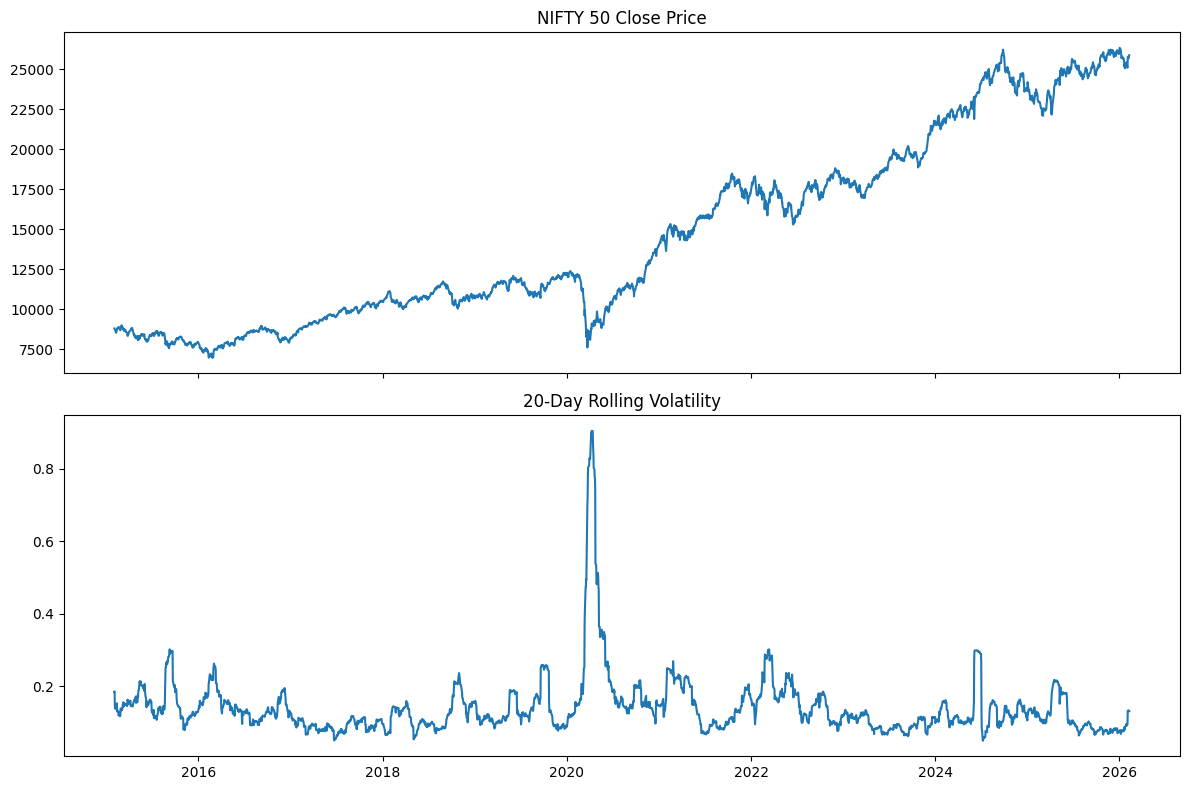

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(df_features.index, df_features["Close"])
ax[0].set_title("NIFTY 50 Close Price")

ax[1].plot(df_features.index, df_features["vol_20d"])
ax[1].set_title("20-Day Rolling Volatility")

plt.tight_layout()
plt.show()


In [7]:
import os

feature_dir = "../data/features"
os.makedirs(feature_dir, exist_ok=True)

feature_path = "../data/features/nifty_50_features.csv"
df_features.to_csv(feature_path)

print("Feature dataset saved successfully.")


Feature dataset saved successfully.
